## Setup and Data Load

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = os.path.join('..', 'dataset', 'raw')   
EMOTIONS = sorted(os.listdir(os.path.join(DATA_DIR, 'train')))
print(EMOTIONS)

def build_index(data_dir, split):
    records = []
    split_dir = os.path.join(data_dir, split)
    for emotion in os.listdir(split_dir):
        emotion_dir = os.path.join(split_dir, emotion)
        for fname in os.listdir(emotion_dir):
            records.append({'split': split, 'emotion': emotion, 'path': os.path.join(emotion_dir, fname)})
    return pd.DataFrame(records)

df_train = build_index(DATA_DIR, 'train')
df_test = build_index(DATA_DIR, 'test')
df = pd.concat([df_train, df_test], ignore_index=True)
print(df.shape)
df.head()

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
(71774, 3)


,split,emotion,path
0,train,disgust,../dataset/raw/train/disgust/Training_32702370...
1,train,disgust,../dataset/raw/train/disgust/Training_24684250...
2,train,disgust,../dataset/raw/train/disgust/Training_98684716...
3,train,disgust,../dataset/raw/train/disgust/Training_33844261...
4,train,disgust,../dataset/raw/train/disgust/Training_85206636...


### Class distribution


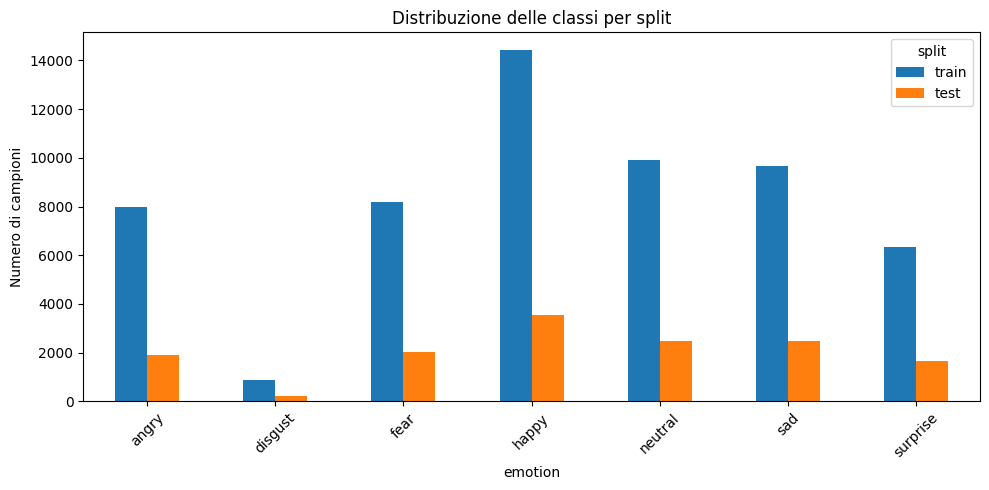

emotion  angry  disgust  fear  happy  neutral   sad  surprise
split                                                        
train     7990      872  8194  14430     9930  9660      6342
test      1916      222  2048   3548     2466  2494      1662

Percentuale sul totale train:
emotion
angry       13.92
disgust      1.52
fear        14.27
happy       25.13
neutral     17.29
sad         16.82
surprise    11.05
Name: train, dtype: float64


In [9]:
counts = df.groupby(['split', 'emotion']).size().unstack(fill_value=0).loc[['train', 'test'], EMOTIONS]
counts.T.plot(kind='bar', figsize=(10, 5))
plt.title('Distribuzione delle classi per split')
plt.ylabel('Numero di campioni')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(counts)
print("\nPercentuale sul totale train:")
print((counts.loc['train'] / counts.loc['train'].sum() * 100).round(2))

In [1]:
n_per_class = 6
fig, axes = plt.subplots(len(EMOTIONS), n_per_class, figsize=(n_per_class * 1.3, len(EMOTIONS) * 1.3))

for i, emotion in enumerate(EMOTIONS):
    samples = df_train[df_train['emotion'] == emotion].sample(n_per_class, random_state=0)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row['path'])
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(emotion, fontsize=9, loc='left')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### Pixel stats

In [12]:
def image_stats(paths, n_sample=200, seed=0):
    sampled = paths.sample(min(n_sample, len(paths)), random_state=seed)
    arrs = np.stack([np.array(Image.open(p)) for p in sampled])
    return arrs.mean(), arrs.std(), arrs.shape[1:]

stats = []
for emotion in EMOTIONS:
    paths = df_train[df_train['emotion'] == emotion]['path']
    mean_b, std_c, shape = image_stats(paths)
    stats.append({'emotion': emotion, 'mean_brightness': mean_b, 'std_contrast': std_c, 'shape': shape})

stats_df = pd.DataFrame(stats)
stats_df

UnidentifiedImageError: cannot identify image file '../dataset/raw/train/angry/Training_33687835.jpg:Zone.Identifier'

### Dim check

In [13]:
# Verifica che tutte le immagini abbiano stessa dimensione (48x48 atteso)
sizes = df_train['path'].sample(500, random_state=0).apply(lambda p: Image.open(p).size)
print(sizes.value_counts())

# Duplicati esatti via hash del contenuto pixel
import hashlib
def file_hash(path):
    return hashlib.md5(open(path, 'rb').read()).hexdigest()

hashes = df_train['path'].sample(2000, random_state=0).apply(file_hash)
print(f"Duplicati nel campione: {hashes.duplicated().sum()} su {len(hashes)}")

UnidentifiedImageError: cannot identify image file '../dataset/raw/train/fear/Training_73426228.jpg:Zone.Identifier'

### Cerchiamo ed eliminaimo i dati duplicati

In [ ]:
# import hashlib

# def file_hash(path):
#     return hashlib.md5(open(path, 'rb').read()).hexdigest()

# # hash su TUTTI i path, sia train che test
# df_train['hash'] = df_train['path'].apply(file_hash)
# df_test['hash'] = df_test['path'].apply(file_hash)

# # duplicati interni a ciascuno split
# train_dup_mask = df_train.duplicated(subset='hash', keep='first')
# test_dup_mask = df_test.duplicated(subset='hash', keep='first')
# print(f"Duplicati interni al train: {train_dup_mask.sum()} su {len(df_train)}")
# print(f"Duplicati interni al test: {test_dup_mask.sum()} su {len(df_test)}")

# df_train_clean = df_train[~train_dup_mask].reset_index(drop=True)
# df_test_clean = df_test[~test_dup_mask].reset_index(drop=True)


Duplicati interni al train: 1236 su 28709
Duplicati interni al test: 86 su 7178


In [ ]:
# # Duplicati TRA train e test: rischio di data leakage.
# # Il test è la fonte di verità: se un'immagine è in entrambi, la rimuoviamo dal train.
# common_hashes = set(df_train_clean['hash']) & set(df_test_clean['hash'])
# print(f"Duplicati tra train e test: {len(common_hashes)}")

# if common_hashes:
#     leak_mask = df_train_clean['hash'].isin(common_hashes)
#     print(f"Rimuovo {leak_mask.sum()} campioni dal train perché presenti anche nel test")
#     df_train_clean = df_train_clean[~leak_mask].reset_index(drop=True)

# print(f"Train pulito: {len(df_train_clean)} campioni (da {len(df_train)})")
# print(f"Test pulito: {len(df_test_clean)} campioni (da {len(df_test)})")


Duplicati tra train e test: 531
Rimuovo 531 campioni dal train perché presenti anche nel test
Train pulito: 26942 campioni (da 28709)
Test pulito: 7092 campioni (da 7178)


salviamo gli indici delle duplicate


In [ ]:
# os.makedirs('../dataset/processed', exist_ok=True)
# df_train_clean.to_csv('../dataset/processed/train_index_clean.csv', index=False)
# df_test_clean.to_csv('../dataset/processed/test_index_clean.csv', index=False)
# print("Salvati train_index_clean.csv e test_index_clean.csv")


Salvati train_index_clean.csv e test_index_clean.csv


: 

In [ ]:
df_train_clean = pd.read_csv('../dataset/processed/train_index_clean.csv')
df_test_clean = pd.read_csv('../dataset/processed/test_index_clean.csv')

print(df_train_clean.shape, df_test_clean.shape)
df_train_clean.head()

(26942, 4) (7092, 4)


,split,emotion,path,hash
0,train,angry,..\dataset\raw\train\angry\Training_10118481.jpg,acd6515d986d2ba2f9027adf88b1616c
1,train,angry,..\dataset\raw\train\angry\Training_10120469.jpg,4f587b7c28777f2131b83e139d5b4cc3
2,train,angry,..\dataset\raw\train\angry\Training_10161559.jpg,307a16006f50533dc443d338be66ae05
3,train,angry,..\dataset\raw\train\angry\Training_1021836.jpg,46cbd8adbbf1ee128246ebfe192864f9
4,train,angry,..\dataset\raw\train\angry\Training_10269675.jpg,d6c81ac92357fa9717f1915bd6a01731


In [ ]:
from sklearn.model_selection import train_test_split

df_trainval = df_train_clean
df_train_final, df_val = train_test_split(
    df_trainval, test_size=0.1, stratify=df_trainval['emotion'], random_state=42
)
print(df_train_final['emotion'].value_counts())
print(df_val['emotion'].value_counts())

emotion
happy       6328
neutral     4340
sad         4209
fear        3428
angry       3411
surprise    2214
disgust      317
Name: count, dtype: int64
emotion
happy       703
neutral     483
sad         468
fear        381
angry       379
surprise    246
disgust      35
Name: count, dtype: int64


In [ ]:
sample_img = np.array(Image.open(df_train_clean['path'].iloc[0]))
print(sample_img.dtype, sample_img.min(), sample_img.max())

uint8 3 197


In [ ]:
df_train_final.to_csv('../dataset/processed/train_final_index.csv', index=False)
df_val.to_csv('../dataset/processed/val_index.csv', index=False)

### Check colore immagini

In [ ]:
modes = df_train_clean['path'].sample(500, random_state=0).apply(lambda p: Image.open(p).mode)
print(modes.value_counts())

path
L    500
Name: count, dtype: int64


In [ ]:
def is_valid(path):
    try:
        Image.open(path).verify()
        return True
    except Exception:
        return False

invalid = df_train_clean['path'].apply(lambda p: not is_valid(p))
print(f"File non validi: {invalid.sum()}")

File non validi: 0


In [ ]:
label2idx = {emotion: idx for idx, emotion in enumerate(EMOTIONS)}
print(label2idx)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
